In [1]:
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt

# Brain Tumor Classification Using Convolutional Neural Networks

## Project Overview

### Dataset
- 253 labeled MRI images
- 202 training images
- 51 testing images

### Results
- Test Accuracy: **78.43%**
- Tumor Detection Rate: **93.55%**
- Correctly classified 40 of 51 MRI scans

In [2]:
import cv2
from sklearn.model_selection import train_test_split


# Path to dataset folder
dataset_path = "brain_tumor_dataset"
base_dir = "splitted_data"


## -----------------------
## Clean and separate data
## -----------------------


# Lists to store images and labels
images = []
labels = []

# Loop through folders
for label in ["yes", "no"]:
    folder_path = os.path.join(dataset_path, label)
    
    for file_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file_name)
        
        # Read image
        img = cv2.imread(img_path)
        
        # Check if img load failed
        if img is None:
            print(f"Failed to load: {img_path}\n")
            
        # Resize all images
        img = cv2.resize(img, (224, 224))
        
        # Store image
        images.append(img)
        
        # Store label
        labels.append(label)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels        
)

# Create folder structure to separate training and testing images
train_yes = os.path.join(base_dir, "train", "yes")
train_no = os.path.join(base_dir, "train", "no")
test_yes = os.path.join(base_dir, "test", "yes")
test_no = os.path.join(base_dir, "test", "no")

for path in [train_yes, train_no, test_yes, test_no]:
    os.makedirs(path, exist_ok=True)


def save_images(images, labels, split_type):
    """
    Saves training and testing images in separate folders
    """
    for i, (img, label) in enumerate(zip(images, labels)):
        if label == "yes":
            folder = os.path.join(base_dir, split_type, "yes")
        else:
            folder = os.path.join(base_dir, split_type, "no")
            
        file_name = f"{label}_{i}.jpg"
        path = os.path.join(folder, file_name)
        
        cv2.imwrite(path, img)


# Separate training and testing images into separate folders
save_images(X_train, y_train, "train")
save_images(X_test, y_test, "test")

### Training Set Balance

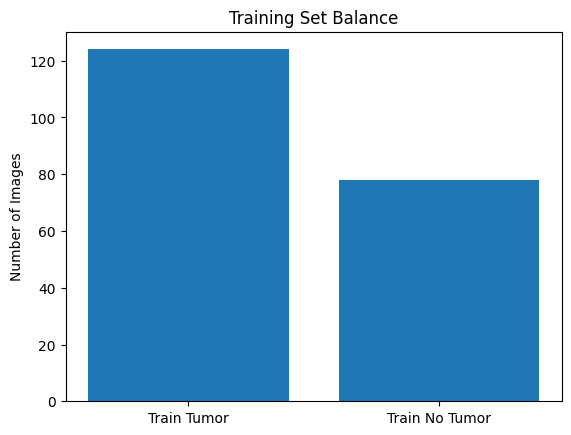

In [3]:
# Count training labels
train_count_yes = y_train.count("yes")
train_count_no = y_train.count("no")

# Plot training data
plt.bar(["Train Tumor", "Train No Tumor"], [train_count_yes, train_count_no])
plt.ylabel("Number of Images")
plt.title("Training Set Balance")
plt.show()

### Testing Set Balance

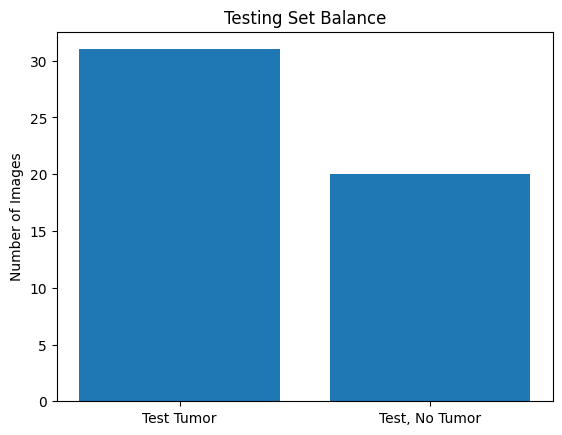

In [4]:
# Count testing lables
test_count_yes = y_test.count("yes")
test_count_no = y_test.count("no")

# Plot testing data
plt.bar(["Test Tumor", "Test, No Tumor"], [test_count_yes, test_count_no])
plt.ylabel("Number of Images")
plt.title("Testing Set Balance")
plt.show()

### Example images

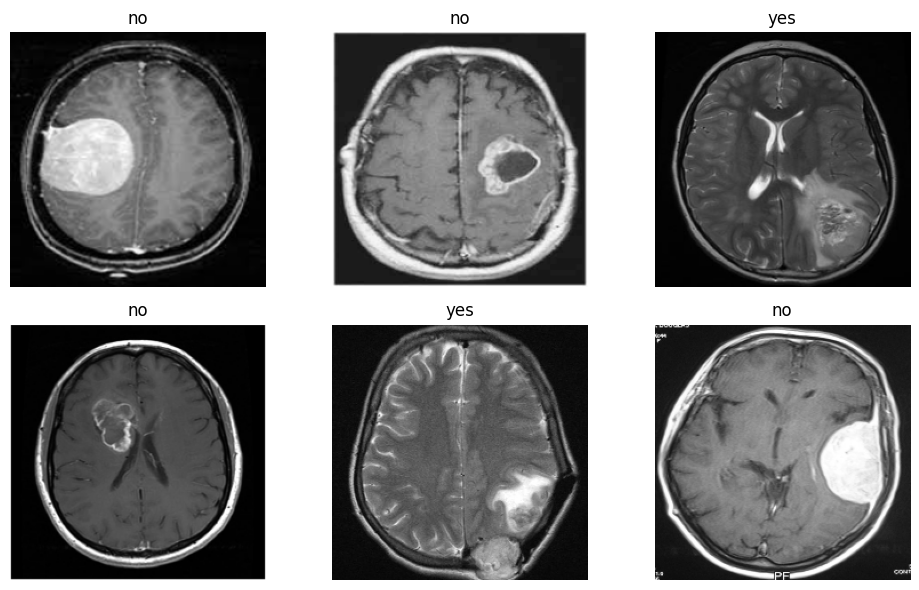

In [5]:
# Show example images
plt.figure(figsize=(10, 6))
for i in range(6):
    index = random.randint(0, len(images) - 1)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(labels[index])
    plt.axis("off")
    
plt.tight_layout()
plt.show()

In [7]:
import pickle
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Rescaling,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
# Dataset Paths

train_dir = 'splitted_data/train'
test_dir = 'splitted_data/test'

# Load Images

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

Found 202 files belonging to 2 classes.
Found 51 files belonging to 2 classes.


In [9]:
# Normalize Images

normalization_layer = Rescaling(1.0 / 255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)


In [17]:
# Build CNN

# Load Existing Model if Exists
MODEL_PATH = "my_model/brain_tumor_detection.keras"
HISTORY_PATH = "model_history/training_history.pkl"

model = Sequential([
    Input(shape=(224, 224, 3)),
    
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
    ),
    
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu"
    ),
    
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dense(
        units=128,
        activation="relu"
    ),
    
    Dropout(0.5),
    
    Dense(
        units=1,
        activation="sigmoid"
    )
])

In [18]:
# Compile model
    
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
# Train Model
    
# Stop cycle if validation loss stops improving in 5 consecutive epochs
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
    
# Train the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=100,
    callbacks=[early_stopping]
)
history_dict = history.history

model.save(MODEL_PATH)
    
with open(HISTORY_PATH, "wb") as f:
    pickle.dump(history_dict, f)
    
print("Model and history saved.")

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 364ms/step - accuracy: 0.5693 - loss: 1.4713 - val_accuracy: 0.8039 - val_loss: 0.6080
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 349ms/step - accuracy: 0.7871 - loss: 0.5879 - val_accuracy: 0.7647 - val_loss: 0.4815
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.7822 - loss: 0.5074 - val_accuracy: 0.8431 - val_loss: 0.4412
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - accuracy: 0.7871 - loss: 0.4710 - val_accuracy: 0.8039 - val_loss: 0.4168
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - accuracy: 0.8119 - loss: 0.4341 - val_accuracy: 0.8627 - val_loss: 0.3661
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.8366 - loss: 0.4012 - val_accuracy: 0.8431 - val_loss: 0.3996
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 384ms/step - accuracy: 0.8515 - loss: 0.3590 - val_accuracy: 0.8431 - val_loss: 0.3102
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 355ms/step - accuracy: 0.8762 - loss: 0.3066 - val_accuracy: 0.8431 - v

In [20]:
# Evaluate Model

model.summary()

loss, accuracy = model.evaluate(test_dataset)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8627 - loss: 0.2371 

Test Loss: 0.2371
Test Accuracy: 0.8627
